In [1]:
import os
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

llm = ChatOpenAI(model="gpt-4o-mini")


In [ ]:
# agent -> tools -> agent -> ... 

In [2]:
@tool
def add(a:int, b:int) -> int:
    """ 두 정수를 더한다"""
    return a+b

@tool
def multiply(a: int, b:int) -> int:
    """두 정수를 곱한다"""
    return a * b

tools = [add, multiply]
llm_with_tools = llm.bind_tools(tools)

In [ ]:
# START - agent -> tool_calls 있다면 -> tools -> agent -> .... -> END
#                     |
#                     -> END

In [3]:
class AgentState(TypedDict):
    messages : Annotated[list, add_messages]

tool_map = {t.name : t for t in tools}

def agent_node(state):
    return {'messages' : [llm_with_tools.invoke(state['messages'])]}

def tools_node(state):
    out = []
    for c in state['messages'][-1].tool_calls:
        out.append(ToolMessage(content=str(tool_map[c['name']].invoke(c['args'])), tool_call_id = c['id']))
    
    return {'messages' : out}

def should_continue(state):
    return "tools" if state['messages'][-1].tool_calls else END

In [4]:
b = StateGraph(AgentState)
b.add_node('agent', agent_node)
b.add_node('tools', tools_node)

b.add_edge(START, 'agent')
b.add_conditional_edges('agent', should_continue, {'tools': 'tools', END:END})
b.add_edge('tools', 'agent')
react_app = b.compile()

In [5]:
r = react_app.invoke({'messages' : [HumanMessage(content="(3+5)*4 는?")]})

In [9]:
r['messages'][-1].content

'(3 + 5) * 4 의 결과는 32입니다.'

In [11]:
[type(m).__name__ for m in r['messages']]

['HumanMessage',
 'AIMessage',
 'ToolMessage',
 'AIMessage',
 'ToolMessage',
 'AIMessage']

In [12]:
@tool
def square(n):
    """정수의 제곱을 반환한다"""
    return n* n

sq_tools = [square]
sq_llm = llm.bind_tools(sq_tools)
sq_map = {t.name:t for t in sq_tools}


In [15]:
class SqState(TypedDict):
    messages : Annotated[list, add_messages]

def sq_agent(state):
    return {'messages' : [sq_llm.invoke(state['messages'])]}

def sq_tn(state):
    return {'messages' : [ToolMessage(content = str(sq_map[c['name']].invoke(c['args'])), tool_call_id=c['id']) for c in state['messages'][-1].tool_calls]}

def sq_route(state):
    return 'tools' if state['messages'][-1].tool_calls else END

sb_ = StateGraph(SqState)
sb_.add_node('agent', sq_agent)
sb_.add_node('tools', sq_tn)

sb_.add_edge(START, 'agent')
sb_.add_conditional_edges('agent', sq_route, {'tools' : 'tools', END : END})
sb_.add_edge('tools', 'agent')
sq_app = sb_.compile()
sq_app.invoke({'messages' : [HumanMessage(content ='7의 제곱은?')]})['messages'][-1].content

'7의 제곱은 49입니다.'

In [ ]:
class AgentState(TypedDict):
    messages : Annotated[list, add_messages]

tool_map = {t.name : t for t in tools}
def agent_node(state):
    return {'messages' : [llm_with_tools.invoke(state['messages'])]}
def tools_node(state):
    out = []
    for c in state['messages'][-1].tool_calls:
        out.append(ToolMessage(content=str(tool_map[c['name']].invoke(c['args'])), tool_call_id = c['id']))
    
    return {'messages' : out}
def should_continue(state):
    return "tools" if state['messages'][-1].tool_calls else END

b = StateGraph(AgentState)
b.add_node('agent', agent_node)
b.add_node('tools', tools_node)

b.add_edge(START, 'agent')
b.add_conditional_edges('agent', should_continue, {'tools': 'tools', END:END})
b.add_edge('tools', 'agent')
react_app = b.compile()

In [16]:
from langgraph.prebuilt import ToolNode, tools_condition

b2 = StateGraph(AgentState)
b2.add_node('agent', agent_node)
b2.add_node('tools', ToolNode(tools))

b2.add_edge(START, 'agent')
b2.add_conditional_edges('agent', tools_condition)
b2.add_edge('tools', 'agent')
auto_app = b2.compile()

In [17]:
r = auto_app.invoke({'messages' : [HumanMessage(content="(3+5)*4 는?")]})
r['messages'][-1].content

'(3 + 5) * 4의 결과는 32입니다.'

In [18]:
for m in r['messages']:
    print(m)
    print()

content='(3+5)*4 는?' additional_kwargs={} response_metadata={} id='5eb49194-9fb4-49c7-829b-8503d74be47b'

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 78, 'total_tokens': 95, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b264835538', 'id': 'chatcmpl-DaJyI052LT23rlnTK1IY9fKS80Nau', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019dde2c-78a4-7dd1-81ed-117805d3eacd-0' tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 5}, 'id': 'call_FoJVXy5rF5n48Rr46QyY4zMm', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 78, 'output_tokens': 17, 'total_tokens': 95, 'input_token_details': {'audio': 0, 'cache_

In [ ]:
def agent_node(state):
    return {'messages' : [llm_with_tools.invoke(state['messages'])]}
def tools_node(state):
    out = []
    for c in state['messages'][-1].tool_calls:
        out.append(ToolMessage(content=str(tool_map[c['name']].invoke(c['args'])), tool_call_id = c['id']))

        
b2 = StateGraph(AgentState)
b2.add_node('agent', agent_node)
b2.add_node('tools', ToolNode(tools))

b2.add_edge(START, 'agent')
b2.add_conditional_edges('agent', tools_condition)
b2.add_edge('tools', 'agent')
auto_app = b2.compile()

In [19]:
@tool
def substract(a, b):
    """a에서 b를 뺀다"""
    return a-b

three_tools = [add, multiply, substract]
three_llm = llm.bind_tools(three_tools)

class ThreeState(TypedDict):
    messages : Annotated[list, add_messages]
        
tb = StateGraph(ThreeState)
tb.add_node('agent', lambda s: {'messages' : [three_llm.invoke(s['messages'])]})
tb.add_node('tools', ToolNode(three_tools))

tb.add_edge(START, 'agent')
tb.add_conditional_edges('agent', tools_condition)
tb.add_edge('tools', 'agent')
three_app = tb.compile()

r = three_app.invoke({'messages' : [HumanMessage(content='100 더하기 5 빼기 2에 3을 곱하면?')]})
print(r['messages'][-1].content)
# 100 더하기 5 빼기 2 에 3을 곱하면?

100 더하기 5 빼기 2에 3을 곱하면 315입니다.


In [20]:
(105-2)*3

309

In [21]:
r = three_app.invoke({'messages' : [HumanMessage(content='100에다가 5를 더한 뒤, 그 결과에서 2를 빼고, 그 결과에 3을 곱하면?')]})
print(r['messages'][-1].content)

계산 결과는 309입니다.


In [ ]:
# 법률 에이전트
# 안녕하세요?      -> general 
# 형법 100조가 뭔가요?  ->  조문검색
# 대법원 2020가 1234 판례 알려줘 -> 판례 검색
# 판례란?  -> 용어 설명

In [22]:
class QState(TypedDict):
    question : str
    qtype: Literal['article', 'case', 'term', 'general']
    answer : str

        
# 음식 분류 라우터를 만들어주세요
# korean, western, asian, other

# korean
# western

def classify(state: QState) -> dict:
    response = llm.invoke([
        SystemMessage(content = """질문을 다음 4가지 카테고리 중 하나로 분류하세요:
        - article : 법률 조문 (~조, ~항)에 대한 질문
        - case : 판례 번호 (예: 2020다1234)나 특정 사건에 대한 질문
        - term : 법률 용어 정의나 개념 설명 질문
        - general : 인사, 일상 대화 등 기타 질문
        
        답변은 반드시 하나의 단어('article', 'case', 'term', 'general')로만 하세요""")
        few_shot_examples = [
            HumanMessage(cotent ='민법 123조 알려줘'),
            AIMessage(content = 'article'), 
            ...
        ]
        ,
        HumanMessage(content = state['question'])
    ])
    qtype = response.content.strip().lower()
    if qtype not in ['article', 'case', 'term', 'general']:  # 'law'
        qtype = 'general'
    
    return {'qtype' : qtype}

def article_search(s) : return {'answer' : f'[조문 검색] {s["question"]}'}
def case_search(s) : return {'answer' : f'[판례 검색] {s["question"]}'}
def term_explain(s) : return {'answer' : f'[용어 설명] {s["question"]}'}
def general_chat(s) : return {'answer' : f'[일반 대화] {s["question"]}'}

def route_by_type(state:QState) -> str:
    return state['qtype']

qb = StateGraph(QState)
qb.add_node('classify', classify)
qb.add_node('article', article_search)
qb.add_node('case', case_search)
qb.add_node('term', term_explain)
qb.add_node('general', general_chat)

qb.add_edge(START, 'classify')
qb.add_conditional_edges('classify', route_by_type, {'article' : 'article', 'case': 'case', 'term': 'term', 'general': 'general'})
qb.add_edge('article', END)
qb.add_edge('case', END)
qb.add_edge('term', END)
qb.add_edge('general', END)

q_app = qb.compile()

In [23]:
q_app.invoke({'question' : '민법 제760조가 뭔가요?', 'qtype' :'general', 'answer':''})

{'question': '민법 제760조가 뭔가요?',
 'qtype': 'case',
 'answer': '[판례 검색] 민법 제760조가 뭔가요?'}

In [24]:
q_app.invoke({'question' : '대법원 2020가 1234 판례 알려줘', 'qtype' :'general', 'answer':''})

{'question': '대법원 2020가 1234 판례 알려줘',
 'qtype': 'case',
 'answer': '[판례 검색] 대법원 2020가 1234 판례 알려줘'}

In [25]:
q_app.invoke({'question' : '안녕하세요?', 'qtype' :'general', 'answer':''})

{'question': '안녕하세요?', 'qtype': 'general', 'answer': '[일반 대화] 안녕하세요?'}

In [27]:
q_app.invoke({'question' : '공소시효란?', 'qtype' :'general', 'answer':''})

{'question': '공소시효란?', 'qtype': 'term', 'answer': '[용어 설명] 공소시효란?'}

In [ ]:
# 음식 분류 라우터를 만들어주세요
# korean, western, asian, other

# korean
# western
# ...

In [ ]:
class QState(TypedDict):
    question : str
    qtype: Literal['article', 'case', 'term', 'general']
    answer : str

def classify(state: QState) -> dict:
    response = llm.invoke([
        few_shot_examples = [
        HumanMessage(content = state['question'])
    ])
    qtype = response.content.strip().lower()
    if qtype not in ['article', 'case', 'term', 'general']:  # 'law'
        qtype = 'general'
    
    return {'qtype' : qtype}

def article_search(s) : return {'answer' : f'[조문 검색] {s["question"]}'}
def case_search(s) : return {'answer' : f'[판례 검색] {s["question"]}'}
def term_explain(s) : return {'answer' : f'[용어 설명] {s["question"]}'}
def general_chat(s) : return {'answer' : f'[일반 대화] {s["question"]}'}

def route_by_type(state:QState) -> str:
    return state['qtype']



In [28]:
class FoodState(TypedDict):
    food : str
    category : Literal['korean', 'western', 'asian', 'other']
    desc : str
        
def f_classify(s):
    r = llm.invoke([
        SystemMessage(content = '음식을 korean/western/asian/other 중 하나로만 답'),
        HumanMessage(content = s['food'])
    ])
    cat = r.content.strip().lower()
    if cat not in ['korean', 'western', 'asian', 'other']:
        cat = 'other'
    return {'category' : cat}

def k(s) : return {'desc' : f"{s['food']} 는 한식"}
def w(s) : return {'desc' : f"{s['food']} 는 양식"}
def a(s) : return {'desc' : f"{s['food']} 는 아시안식"}
def o(s) : return {'desc' : f"{s['food']} 는 기타"}

fb = StateGraph(FoodState)
fb.add_node("classify", f_classify)
fb.add_node('korean', k)
fb.add_node('western', w)
fb.add_node('asian', a)
fb.add_node('other', o)

fb.add_edge(START, 'classify')
fb.add_conditional_edges('classify', lambda s: s['category'], {'korean':'korean', 'western':'western', 'asian':'asian', 'other':'other'})
for n in ['korean', 'western', 'asian', 'other']:
    fb.add_edge(n, END)
    
food_app = fb.compile()

In [29]:
food_app.invoke({'food': '김치찌개', 'category':'other', 'desc':''})

{'food': '김치찌개', 'category': 'korean', 'desc': '김치찌개 는 한식'}

In [ ]:
from langgraph.prebuilt import ToolNode, tools_condition

b2 = StateGraph(AgentState)
b2.add_node('agent', agent_node)
b2.add_node('tools', ToolNode(tools))

b2.add_edge(START, 'agent')
b2.add_conditional_edges('agent', tools_condition)
b2.add_edge('tools', 'agent')
auto_app = b2.compile()
auto_app.invoke("")

In [30]:
memory = MemorySaver()
mem_app = b2.compile(checkpointer=memory)

In [31]:
cfg = {'configurable' : {'thread_id' : 'alice'}}
mem_app.invoke({'messages' : [HumanMessage(content='내 이름은 앨리스야')]}, config=cfg)

{'messages': [HumanMessage(content='내 이름은 앨리스야', additional_kwargs={}, response_metadata={}, id='55070de2-7668-4eb4-a2e7-471743ff8f0e'),
  AIMessage(content='안녕하세요, 앨리스! 만나서 반가워요. 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 77, 'total_tokens': 99, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b264835538', 'id': 'chatcmpl-DaL2NJ0OqL6dzJgrAmnKTqcxkGdla', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dde6a-faba-7453-97ba-1df5a4463af2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 22, 'total_tokens': 99, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_

In [33]:
r = mem_app.invoke({'messages' : [HumanMessage(content='내 이름이 뭐였지?')]}, config=cfg)

In [35]:
len(r['messages'])

6

In [37]:
cfg_bob = {'configurable' : {'thread_id' : 'bob'}}
r = mem_app.invoke({'messages' : [HumanMessage(content='내 이름이 뭐야?')]}, config=cfg_bob)
r['messages'][-1].content

'저는 당신의 이름을 알 수 없습니다. 당신의 이름을 알려주시면 그에 대한 대화를 나눌 수 있습니다!'

In [39]:
prefs = {'u1' : '피자', 'u2' : '초밥', 'u3' : '떡볶이'}
for uid, food in prefs.items():
    mem_app.invoke({'messages' : [HumanMessage(content=f'내가 좋아하는 음식은 {food}야')]}, config={'configurable' : {'thread_id' : uid}})
    
for uid in prefs:
    r = mem_app.invoke({'messages' : [HumanMessage(content=f'내가 좋아하는 음식은?')]}, config={'configurable' : {'thread_id' : uid}})
    print(f"[{uid}] {r['messages'][-1].content}")

[u1] 당신이 좋아하는 음식은 피자입니다! 피자의 다양한 종류와 맛이 많아서 정말 맛있죠. 피자에 대해 더 이야기하고 싶으신가요? 아니면 다른 질문이 있으신가요?
[u2] 당신이 좋아하는 음식은 초밥입니다! 초밥의 다양한 종류와 신선한 재료들이 매력적이죠. 다른 음식들도 좋아하시는지 궁금하네요!
[u3] 당신이 좋아하는 음식은 떡볶이입니다! 매콤하고 맛있는 음식이죠. 떡볶이에 대해 더 이야기하고 싶거나 다른 음식을 추천받고 싶으신가요?


In [40]:
# get_state
cfg_a = {'configurable' : {'thread_id' : 'alice'}}
snap = mem_app.get_state(cfg_a)

In [43]:
len(snap.values['messages'])

6

In [44]:
snap.next

()

In [47]:
history = list(mem_app.get_state_history(cfg_a))
len(history)

9

In [48]:
history[-1].values.get('messages', [])

[]

In [49]:
# update_state
cfg_x = {'configurable' : {'thread_id' : 'manual'}}
mem_app.update_state(cfg_x, {'messages' : [HumanMessage(content='안녕!')]})
snap = mem_app.get_state(cfg_x)

In [50]:
snap

StateSnapshot(values={'messages': [HumanMessage(content='안녕!', additional_kwargs={}, response_metadata={}, id='8b4a30d9-c4a2-4c13-864c-8e2095f09cd0')]}, next=('agent',), config={'configurable': {'thread_id': 'manual', 'checkpoint_ns': '', 'checkpoint_id': '1f144944-77fc-6286-8000-bad8ca91cc8a'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-04-30T12:58:27.059967+00:00', parent_config=None, tasks=(PregelTask(id='da38cdea-48d9-8014-9b90-9ec69f314a06', name='agent', path=('__pregel_pull', 'agent'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [51]:
for m in snap.values['messages']:
    print(type(m).__name__)

HumanMessage


In [52]:
[type(m).__name__ for m in snap.values['messages']]

['HumanMessage']

In [53]:
r = mem_app.invoke(None, config=cfg_x)
r['messages']

[HumanMessage(content='안녕!', additional_kwargs={}, response_metadata={}, id='8b4a30d9-c4a2-4c13-864c-8e2095f09cd0'),
 AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 73, 'total_tokens': 84, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0628d073e2', 'id': 'chatcmpl-DaLIF37DtX65iAw2nwiiPv4smoWv8', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dde7a-027a-7a22-8a0b-e58ce93dca28-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 11, 'total_tokens': 84, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 

In [54]:
r['messages'][-1].content

'안녕하세요! 어떻게 도와드릴까요?'

In [ ]:
# agent -> .... -> [stop]       tools

In [67]:
agent_break = b2.compile(checkpointer=MemorySaver(), interrupt_before = ['agent'])  # agent
cfg_tmp =  {'configurable' : {'thread_id' : 'agent-break1'}}
agent_break.invoke({'message' : [HumanMessage(content ='아무거나 물어봄')]}, config = cfg_tmp)
st = agent_break.get_state(cfg_tmp)

In [65]:
st.next

('agent',)

In [68]:
st.values['messages']

[]

In [55]:
# interrupt_before
hitl_app = b2.compile(checkpointer=MemorySaver(), interrupt_before = ['tools'])  # agent

hitl_app_tmp.invoke({'message' : [HumanMessage(content ='아무거나 물어봄')]}, config = cfg_tmp)

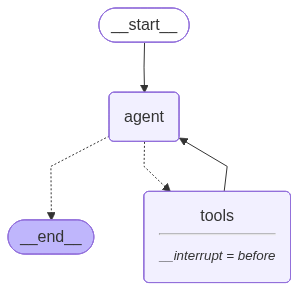

In [56]:
hitl_app

In [57]:
cfg_h = {'configurable' : {'thread_id' : 'hitl-1'}}
hitl_app.invoke({'messages' : [HumanMessage(content = '100 더하기 200은?')]}, config=cfg_h)

{'messages': [HumanMessage(content='100 더하기 200은?', additional_kwargs={}, response_metadata={}, id='8547d3d8-c235-47a3-bfb1-1e58d732b0c1'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 77, 'total_tokens': 94, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0628d073e2', 'id': 'chatcmpl-DaLNbPTJWxGXk9TfsmAyGZa9ZAZcc', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dde7f-1201-7580-a075-d374defff55b-0', tool_calls=[{'name': 'add', 'args': {'a': 100, 'b': 200}, 'id': 'call_MC0VlRcukFIdOxVYVLgCw7Oh', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 17, 'total_

In [58]:
state = hitl_app.get_state(cfg_h)

In [60]:
state.next

('tools',)

In [61]:
state

StateSnapshot(values={'messages': [HumanMessage(content='100 더하기 200은?', additional_kwargs={}, response_metadata={}, id='8547d3d8-c235-47a3-bfb1-1e58d732b0c1'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 77, 'total_tokens': 94, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0628d073e2', 'id': 'chatcmpl-DaLNbPTJWxGXk9TfsmAyGZa9ZAZcc', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dde7f-1201-7580-a075-d374defff55b-0', tool_calls=[{'name': 'add', 'args': {'a': 100, 'b': 200}, 'id': 'call_MC0VlRcukFIdOxVYVLgCw7Oh', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_t

In [62]:
pending = state.values['messages'][-1].tool_calls[0]
pending

{'name': 'add',
 'args': {'a': 100, 'b': 200},
 'id': 'call_MC0VlRcukFIdOxVYVLgCw7Oh',
 'type': 'tool_call'}

In [69]:
result = hitl_app.invoke(None, config= cfg_h)

In [70]:
result

{'messages': [HumanMessage(content='100 더하기 200은?', additional_kwargs={}, response_metadata={}, id='8547d3d8-c235-47a3-bfb1-1e58d732b0c1'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 77, 'total_tokens': 94, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0628d073e2', 'id': 'chatcmpl-DaLNbPTJWxGXk9TfsmAyGZa9ZAZcc', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dde7f-1201-7580-a075-d374defff55b-0', tool_calls=[{'name': 'add', 'args': {'a': 100, 'b': 200}, 'id': 'call_MC0VlRcukFIdOxVYVLgCw7Oh', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 17, 'total_

In [71]:
cfg_r = {'configurable' : {'thread_id' : 'hhhh'}}
hitl_app.invoke({'messages' : [HumanMessage(content = '50 곱하기 4는?')]}, config=cfg_r)

hitl_app.update_state(cfg_r, {'messages' : [AIMessage(content='죄송합니다. 정책상 도구 실행을 거부합니다')]})

r = hitl_app.invoke(None, config=cfg_r)


In [72]:
r['messages'][-1].content

'죄송합니다. 정책상 도구 실행을 거부합니다'